In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

100%|█████████████████████████████████████████████████████████████████████████████| 66.0M/66.0M [01:06<00:00, 1.03MB/s]

Extracting files...


Path to dataset files: C:\Users\Anshika\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


Dataset Shape: (50000, 31)
            Time         V1        V2         V3        V4         V5  \
43428    41505.0 -16.526507  8.584972 -18.649853  9.505594 -13.793819   
49906    44261.0   0.339812 -2.743745  -0.134070 -1.385729  -1.451413   
29474    35484.0   1.399590 -0.590701   0.168619 -1.029950  -0.539806   
276481  167123.0  -0.432071  1.647895  -1.669361 -0.349504   0.785785   
278846  168473.0   2.014160 -0.137394  -1.015839  0.327269  -0.182179   

              V6         V7        V8        V9  ...       V21       V22  \
43428  -2.832404 -16.701694  7.517344 -8.507059  ...  1.190739 -1.127670   
49906   1.015887  -0.524379  0.224060  0.899746  ... -0.213436 -0.942525   
29474   0.040444  -0.712567  0.002299 -0.971747  ...  0.102398  0.168269   
276481 -0.630647   0.276990  0.586025 -0.484715  ...  0.358932  0.873663   
278846 -0.956571   0.043241 -0.160746  0.363241  ... -0.238644 -0.616400   

             V23       V24       V25       V26       V27       V28  Amount  \

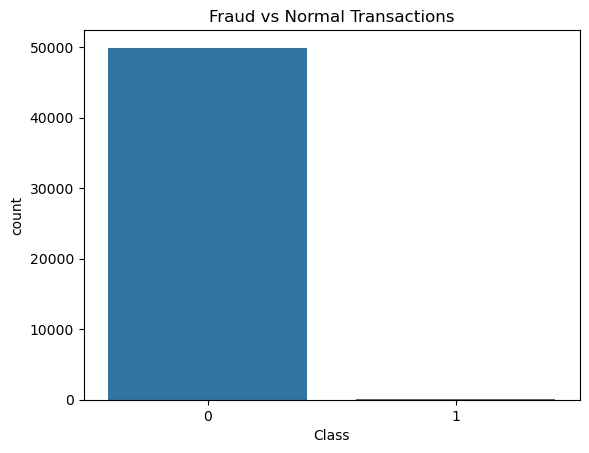

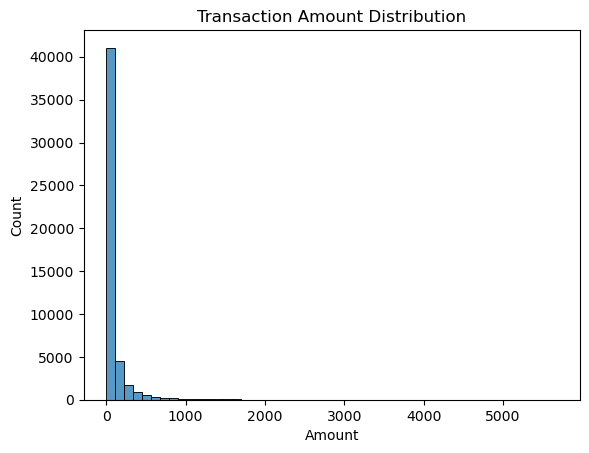

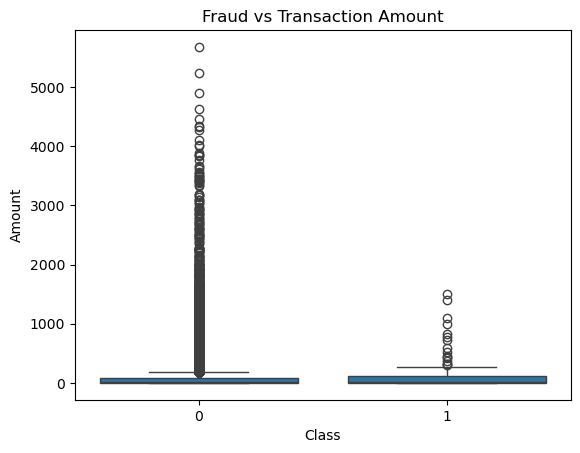

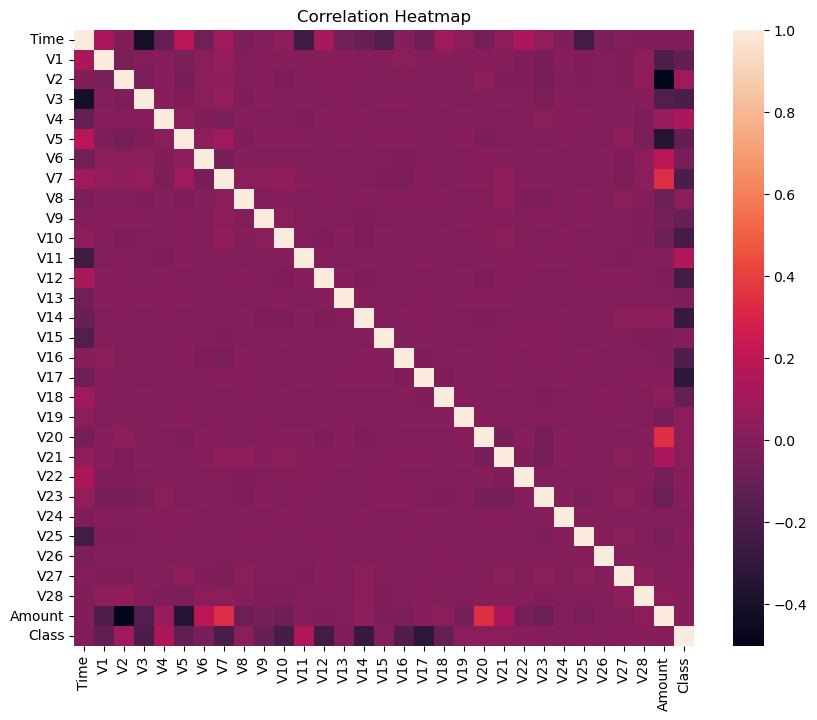

After SMOTE: Class
1    49917
0    49917
Name: count, dtype: int64

Confusion Matrix:
[[10057     7]
 [   61  9842]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     10064
           1       1.00      0.99      1.00      9903

    accuracy                           1.00     19967
   macro avg       1.00      1.00      1.00     19967
weighted avg       1.00      1.00      1.00     19967



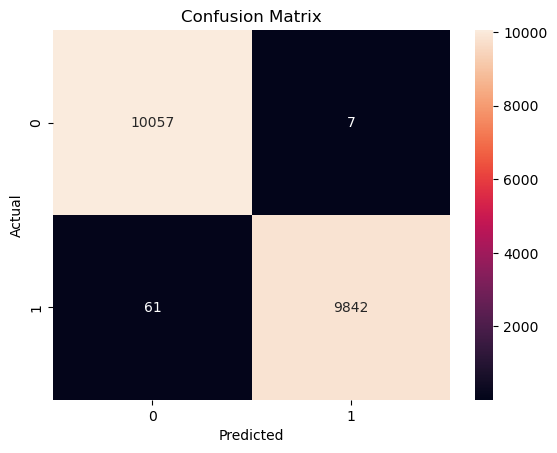

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# -----------------------------
# 1 Load Dataset
# -----------------------------
path = r"C:\Users\Anshika\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3\creditcard.csv"

df = pd.read_csv(path)

# Use smaller sample to speed up
df = df.sample(n=50000, random_state=42)

print("Dataset Shape:", df.shape)
print(df.head())

# -----------------------------
# 2 Dataset Information
# -----------------------------
print(df.info())
print(df.describe())

# Missing values
print("Missing Values:")
print(df.isnull().sum())

# -----------------------------
# 3 Data Visualization
# -----------------------------

# Class distribution
plt.figure()
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

# Transaction amount distribution
plt.figure()
sns.histplot(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

# Boxplot
plt.figure()
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Fraud vs Transaction Amount")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr())
plt.title("Correlation Heatmap")
plt.show()

# -----------------------------
# 4 Feature Scaling
# -----------------------------
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

# -----------------------------
# 5 Feature Selection
# -----------------------------
X = df.drop('Class', axis=1)
y = df['Class']

# -----------------------------
# 6 Handle Imbalanced Data
# -----------------------------
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

print("After SMOTE:", y_res.value_counts())

# -----------------------------
# 7 Train Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

# -----------------------------
# 8 Model Training
# -----------------------------
model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

# -----------------------------
# 9 Prediction
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# 10 Model Evaluation
# -----------------------------
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# -----------------------------
# 11 Confusion Matrix Visualization
# -----------------------------
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()